# Error Propagation using Random Gaussian Numbers

## References:
- Barlow: page 48-61

## Author, Date
- Author: Peter Resch
- Date:   10th of November 2025

In [1]:
import numpy as np                                     # Mat Library
import matplotlib.pyplot as plt                        # Plots and figures
from iminuit import Minuit                             # The actual fitting tool, better than scipy's
import sys                                             # Modules to see files and folders in directories

In [2]:
mu1   =  3.5
sig1  =  0.4
mu2   =  0.8
sig2  =  0.2
rho12 =  0.0            #-1.0 <= rho12 <= 1.0

## Error propagation - Simulation

In [3]:
N_exp = 10000           # Number of "experiments"
save_plots = False
r = np.random
r.seed(42)


# Produce random numbers with (a possible) correlation:
covar_matrix = np.array([[sig1**2, rho12*sig1*sig2],
                [rho12*sig1*sig2, sig2**2]])

x12_all = np.random.multivariate_normal([mu1, mu2], covar_matrix, size=N_exp)

#print(x12_all)

# Now we use the input variables (x1 and x2) to calculate y:
y_all = x12_all[:,0] - 2*x12_all[:,1]         #formula spaceholder

#### Plot in 2D Histogram

x_min: 0.0 m_max: 6.0
y_min: -1.0 y_max: 2.0


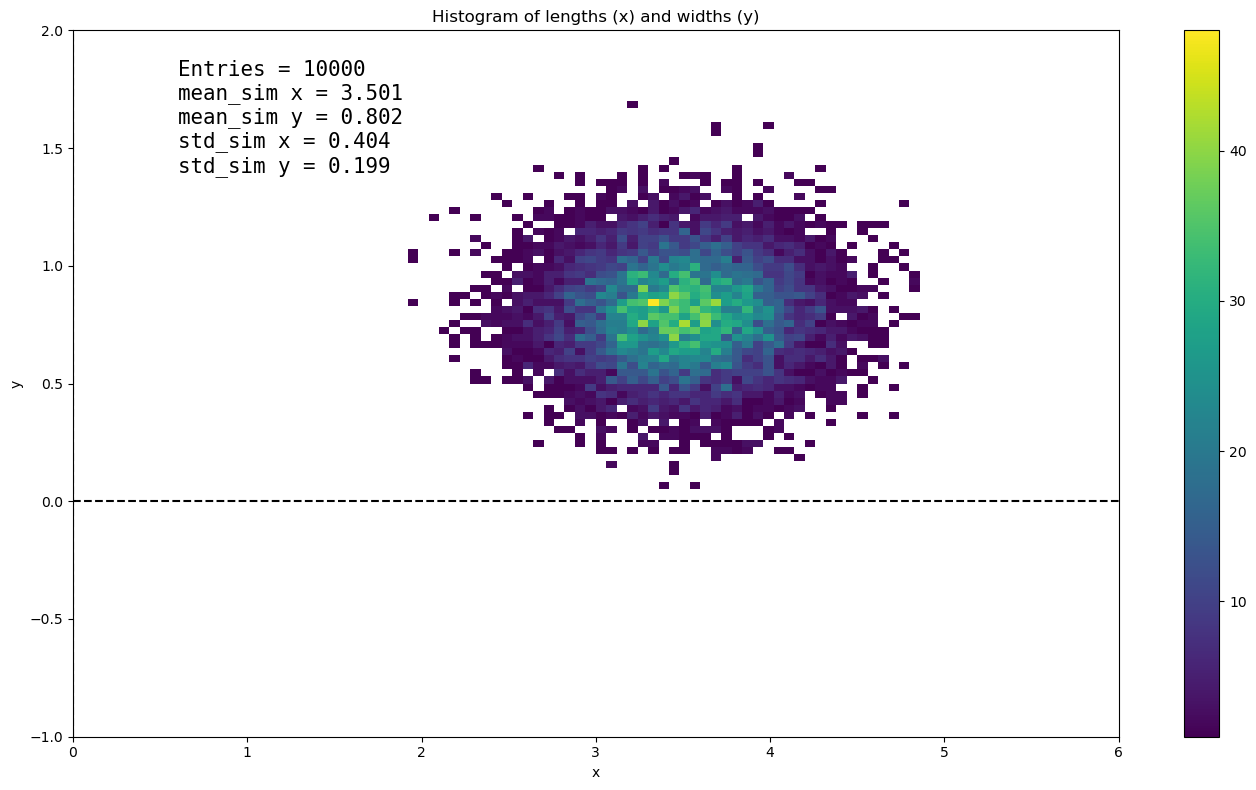

In [4]:
fig, ax = plt.subplots(figsize=(14, 8))

x_min, x_max=np.round(mu1-6*sig1-1), np.round(mu1+6*sig1)
print("x_min:",x_min, "m_max:", x_max)
y_min, y_max=np.round(mu2-6*sig2-1), np.round(mu2+6*sig2)
print("y_min:",y_min,"y_max:",y_max)

counts, xedges, yedges, im = ax.hist2d(x12_all[:,0], x12_all[:,1], bins=[100, 100], range=[[x_min, x_max], [y_min, y_max]], cmin=1)
ax.plot([x_min, x_max], [0, 0], "--k")    # dashed black line from [x1, x2], [y1, y2] with dashed line
ax.plot([0.0, 0.0], [y_min, y_max], "--k")

fig.colorbar(im)
ax.set(title='Histogram of lengths (x) and widths (y)', xlabel='x', ylabel='y')

plot_info = [f"Entries = {len(x12_all)}",
             f"mean_sim x = {x12_all[:,0].mean():5.3f}",
             f"mean_sim y = {x12_all[:,1].mean():5.3f}",
             f"std_sim x = {x12_all[:,0].std(ddof=1):5.3f}",
             f"std_sim y = {x12_all[:,1].std(ddof=1):5.3f}"]
ax.text(0.1, 0.8, "\n".join(plot_info), family='monospace', fontsize=15, transform = ax.transAxes);

fig.tight_layout()
#fig


## Resulting distribution:

  mean = 1.898,    std = 0.568


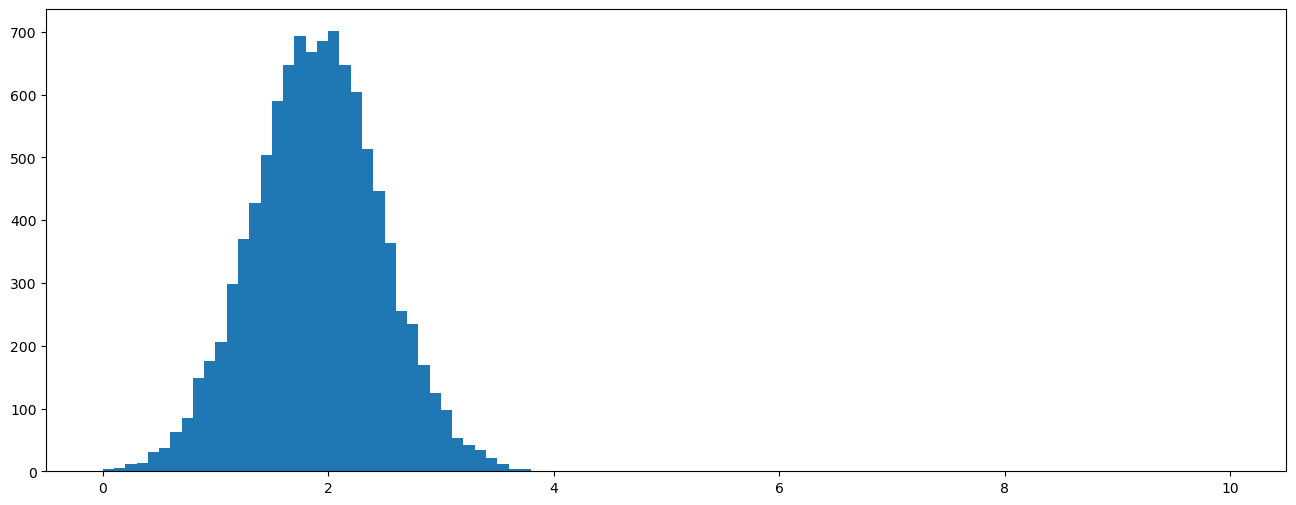

In [5]:
# Always control the binning and range!
nbins = 100
xmin, xmax = 0.0, 10.0
binwidth = (xmax-xmin)/nbins

fig2, ax2 = plt.subplots(figsize=(16, 6));
counts, bin_edges, _ = ax2.hist(y_all, nbins, range=(xmin, xmax), histtype='stepfilled', linewidth=2)
#bin_centers = (bin_edges[1:] + bin_edges[:-1])/2
s_counts = np.sqrt(counts)


mean_sim = y_all.mean()
std_sim = y_all.std(ddof=1)
print(f"  mean = {mean_sim:5.3f},    std = {std_sim:5.3f}")

In [6]:
if save_plots :
    fig.savefig("Dist_2Dgauss.pdf")

#### Gaussian Overlay

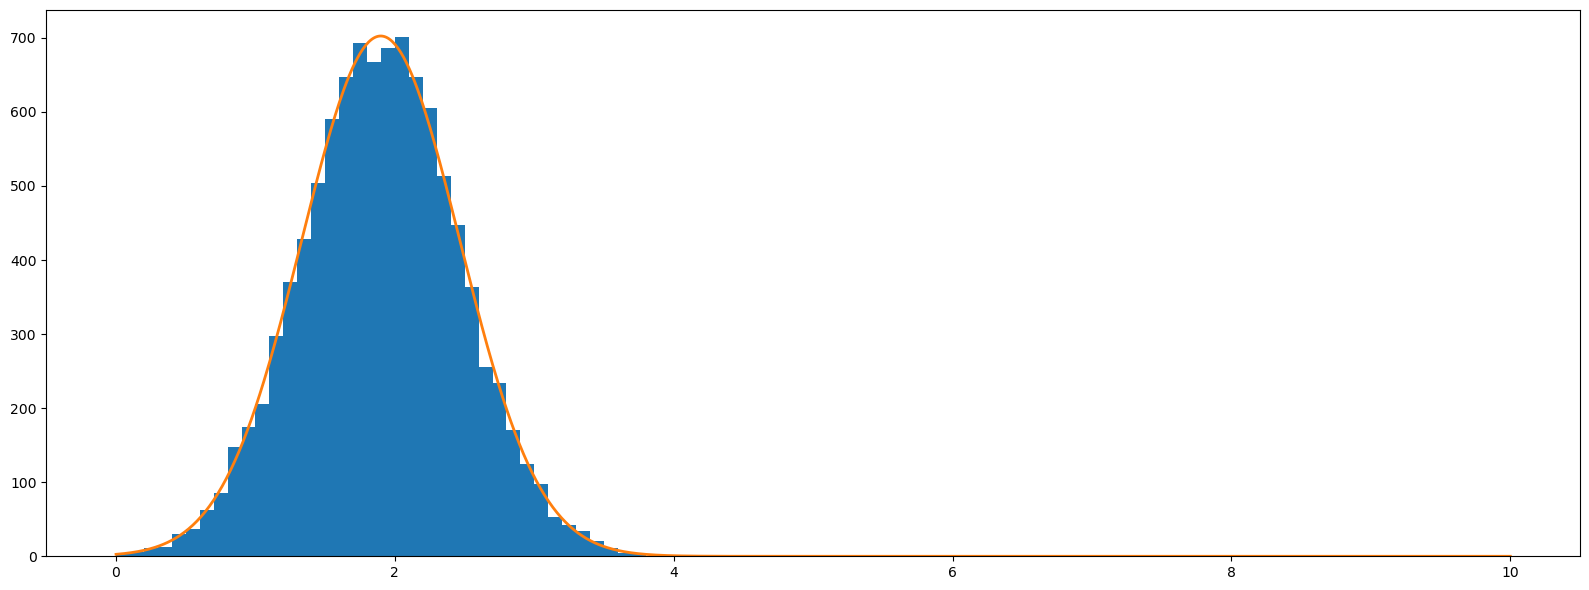

In [7]:
def gaussian(x, N, mu, sigma):
    return N * binwidth / (sigma*np.sqrt(2*np.pi)) * np.exp(-0.5* (x-mu)**2/sigma**2)
    
x_gauss = np.linspace(xmin, xmax, 1000)
y_gauss = gaussian(x_gauss, N_exp, mean_sim, std_sim)
ax2.plot(x_gauss, y_gauss, linewidth=2)
fig2.tight_layout()
fig2

In [8]:
if save_plots:
    fig2.savefig("Dist_ErrorProp.pdf")